# Telecom Customer Churn Analysis

## Data Loading

Import the required libraries and load the telecom customer churn dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Load dataset
df = pd.read_csv(r"C:\Users\Abc\Desktop\Telecom Customer churn\Data\Telco-Customer-Churn.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Data Quality Assessment

The objective of this step is to evaluate the quality of the dataset before analysis. This includes checking the dataset dimensions, data types, missing values, duplicate records, and ensuring that numerical columns are stored in the correct format.

### 1. Dataset Shape

Check the number of rows and columns in the dataset.

In [2]:
print(df.shape)

(7043, 21)


### 2. Dataset Information

Examine column names, data types, and non-null values.

In [3]:

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3. Data Types

Verify that each column has the appropriate data type.


In [4]:
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


### 4. Missing Value Analysis

Identify missing values present in each column.

In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 5. Duplicate Value Analysis

Check for duplicate records in the dataset

In [6]:
print(df.duplicated().sum())

0


### 6. Data Type Conversion

Convert the *TotalCharges* column from object (string) to a numeric data type.

In [7]:

print((df['TotalCharges'] == ' ').sum())
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df['TotalCharges'].isnull().sum())
df.dropna(inplace= True)

11
11


## Summary Statistics

Generate descriptive statistics for the numerical variables to understand their central tendency, spread, minimum, maximum, and quartile values.

The numerical columns analyzed are:

- Tenure
- MonthlyCharges
- TotalCharges

In [8]:
#Summary Statistics -

print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())


            tenure  MonthlyCharges  TotalCharges
count  7032.000000     7032.000000   7032.000000
mean     32.421786       64.798208   2283.300441
std      24.545260       30.085974   2266.771362
min       1.000000       18.250000     18.800000
25%       9.000000       35.587500    401.450000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.862500   3794.737500
max      72.000000      118.750000   8684.800000


## Inference

- The dataset contains **7,043 customers**. The **TotalCharges** column has **7,032** valid values, indicating that **11 values were missing** and were converted during data preprocessing.

- The average customer tenure is **32.37 months**, with values ranging from **0 to 72 months**. This indicates that the dataset includes both new and long-term customers.

- The average monthly charge is **64.76**, with charges varying from **18.25** to **118.75**. This shows a wide range of subscription plans.

- The average total charge paid by customers is **2,283.30**, with values ranging from **18.80** to **8,684.80**. Customers with longer tenure generally accumulate higher total charges.

- The standard deviation of **Tenure**, **MonthlyCharges**, and **TotalCharges** is relatively high, indicating considerable variability among customers.

- The median (50th percentile) tenure is **29 months**, meaning that half of the customers have stayed with the company for less than 29 months.

- Overall, the numerical features exhibit a broad range of values, making them suitable for further visualization, outlier detection, and machine learning analysis.

## Univariate Analysis

Analyze the distribution of individual variables using appropriate visualizations.

### Categorical Variables
- Count Plot

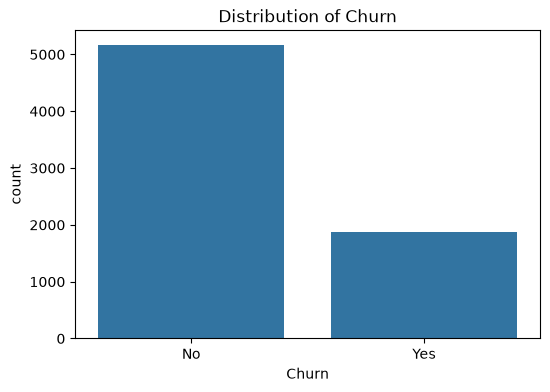

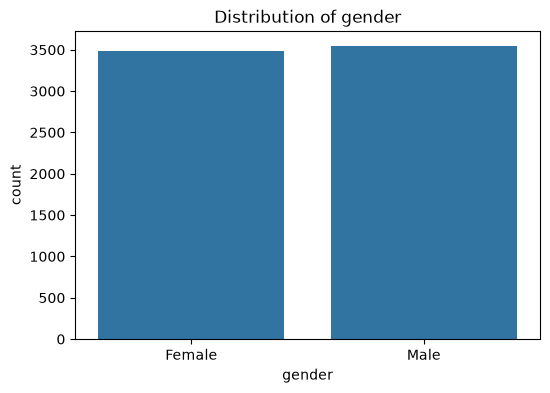

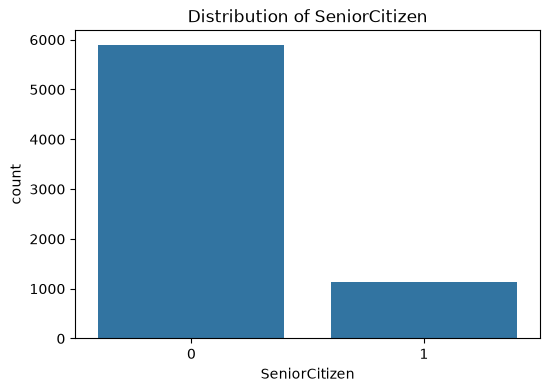

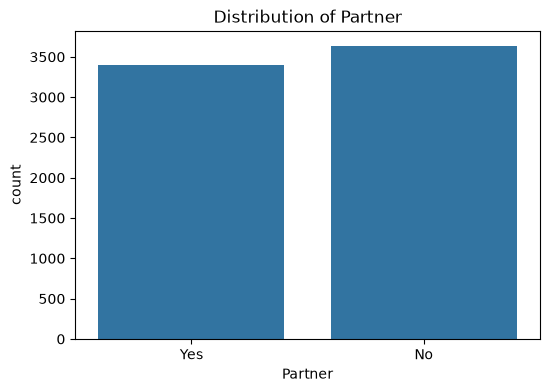

In [ ]:
#Univariate Analysis
categorical_columns = [
    'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'InternetService', 'Contract', 'PaymentMethod',
    'PaperlessBilling', 'OnlineSecurity', 'TechSupport'
]

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x = col, data= df)
    plt.title(f"Distribution of {col}")
    plt.show()

###  Distribution of Churn
### Inference:
- Most customers are retained, while a smaller proportion have churned.
- The dataset is moderately imbalanced, with approximately 73% retained and 27% churned customers.
- This indicates that although most customers stay with the company, customer churn remains a significant business concern.

### Distribution of Gender
### Inference:
- Male and female customers are almost equally distributed.
- The dataset is balanced with respect to gender.
- There is no major gender imbalance in the customer population.

### Distribution of Senior Citizen
### Inference:
- The majority of customers are non-senior citizens.
- Senior citizens represent only a small proportion of the customer base.
- The dataset is dominated by younger or middle-aged customers.

### Distribution of Partner
### Inference:
- Customers with and without partners are almost equally represented in the dataset.
- There is no significant imbalance between the two groups.
- Partner status alone may not strongly influence customer distribution.

### Distribution of Dependents
### Inference:
- A majority of customers do not have dependents.
- Customers with dependents represent a smaller portion of the customer base.
- The dataset is dominated by customers without dependents

###  Distribution of Internet Service
### Inference:
- Fiber Optic is the most commonly used internet service.
- DSL is the second most popular service.
- A smaller number of customers do not use internet services.
- Internet service type is likely to be an important feature in churn prediction.

### Distribution of Contract
### Inference:
- Most customers have Month-to-Month contracts.
- One-Year and Two-Year contracts have significantly fewer customers.
- This indicates that most customers prefer flexible subscription plans.

### Distribution of Payment Method
### Inference:
- Electronic Check is the most frequently used payment method.
- Mailed Check, Bank Transfer (Automatic), and Credit Card (Automatic) are used by comparatively fewer customers.
- Customer preference is skewed toward electronic payment methods.

### Distribution of Paperless Billing
### Inference:
- Most customers have Paperless Billing enabled.
- A smaller proportion of customers still use traditional paper billing.
- This indicates that digital billing is the preferred option among customers.

### Distribution of Online Security
### Inference:
- Most customers do not have Online Security.
- Fewer customers have subscribed to the Online Security service.
- A considerable number of customers do not have internet service, so Online Security is not applicable to them.
- This suggests that Online Security is not widely adopted among internet users.

### Distribution of Tech Support
### Inference:
- Most customers do not subscribe to Tech Support.
- A smaller proportion of customers have Tech Support enabled.
- Some customers do not have internet service, making Tech Support unavailable to them.
- Tech Support adoption is relatively low.


### Numerical Variables
- Histogram
- Box Plot

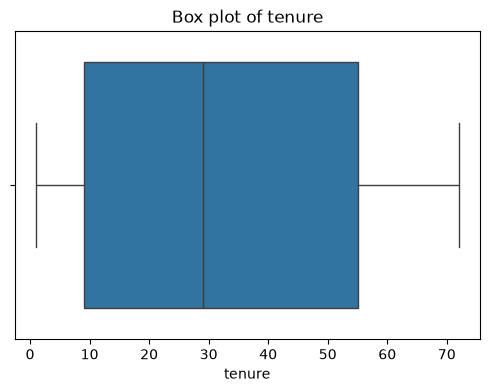

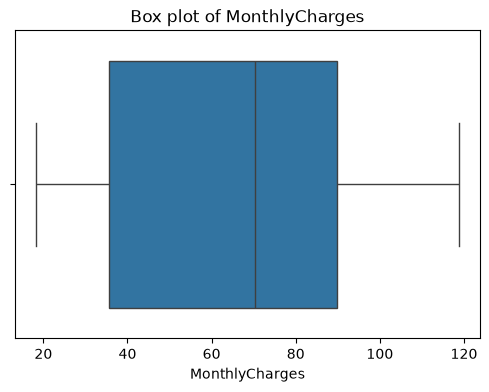

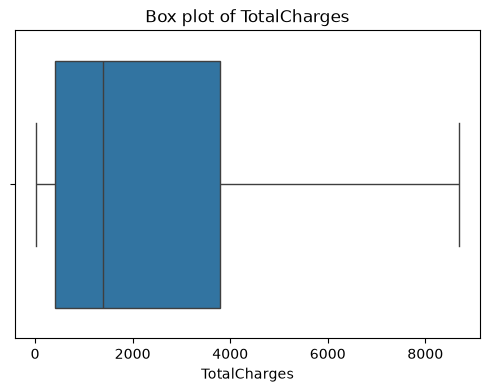

In [ ]:
numeric_col = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])
    plt.title(f"Box plot of {col}")
    plt.show()

### Box Plot of Tenure
### Inference:
- Customer tenure ranges from 0 to 72 months.
- The median tenure is approximately 29 months.
- There are no significant outliers.
- The dataset contains both new and long-term customers, indicating a diverse customer base.

### Box Plot of Monthly Charges
### Inference:
- Monthly charges range approximately from ₹18 to ₹119.
- The median monthly charge is around ₹70.
- No significant outliers are observed, indicating that most customers pay within a reasonable range.
- Customers are subscribed to a variety of plans with different pricing.

### Box Plot of Total Charges
### Inference:
- Total charges vary from approximately ₹19 to ₹8,685.
- The distribution is positively skewed because customers with longer tenure accumulate higher total charges.
- No major outliers are observed.
- Higher total charges are mainly associated with long-term customers.

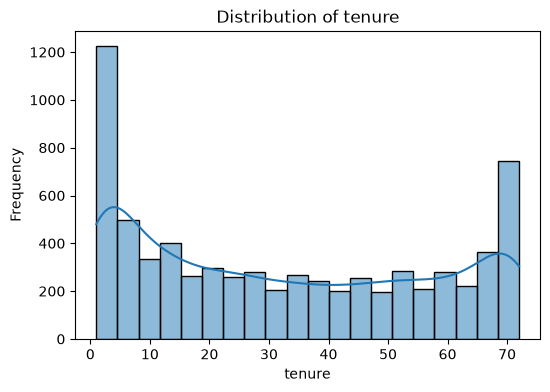

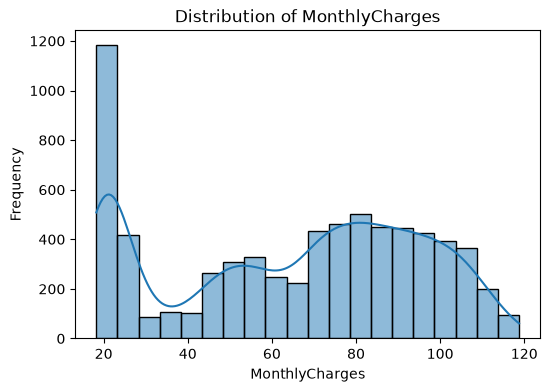

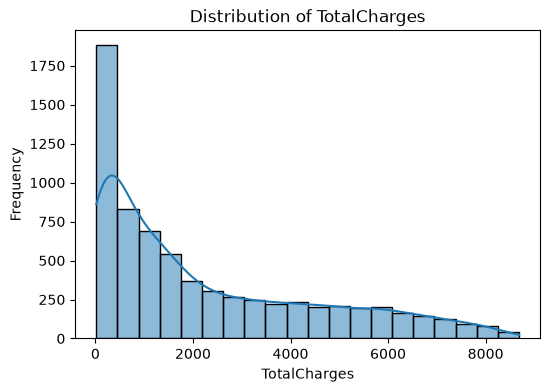

In [ ]:
#Histograms -
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Histogram of Tenure

- There is a high concentration of customers with very low tenure (new customers) and very high tenure (long-term customers).
- Fewer customers fall in the middle tenure range.
- This suggests the company has both newly acquired customers and a loyal long-term customer base.

### Histogram of Monthly Charges

- Monthly charges range from approximately ₹18 to ₹119.
- Most customers pay between ₹60 and ₹100 per month.
- The distribution is not perfectly normal, indicating customers subscribe to different service plans with varying prices.

### Histogram of Total Charges

- The distribution is positively (right) skewed.
- Most customers have relatively low total charges.
- A smaller number of long-term customers have accumulated very high total charges over time.

## Bivariate Analysis

Analyze the relationship between each important feature and the target variable (*Churn*)

### Categorical Variables vs Churn
- Count Plot with Hue

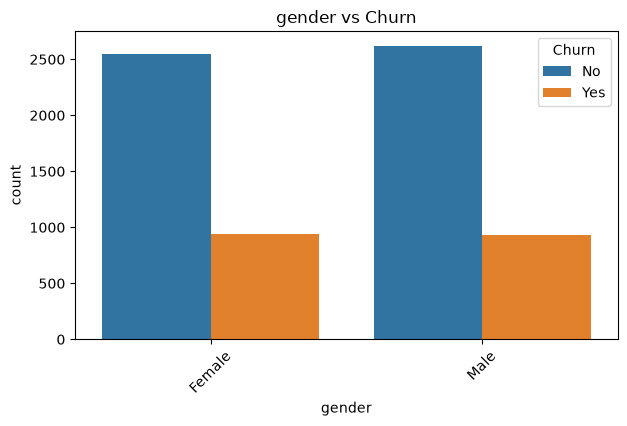

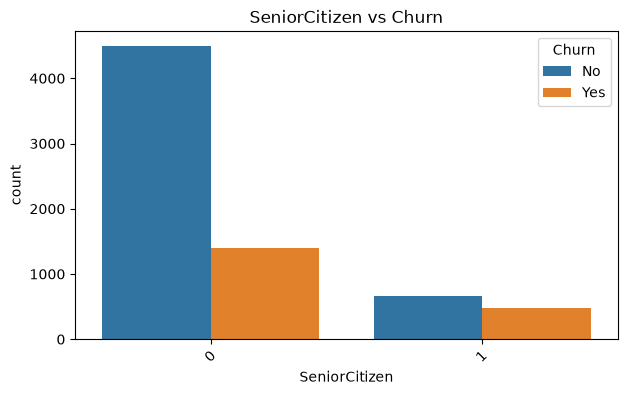

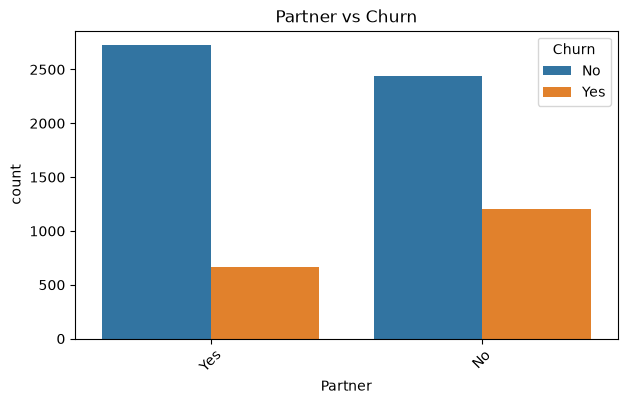

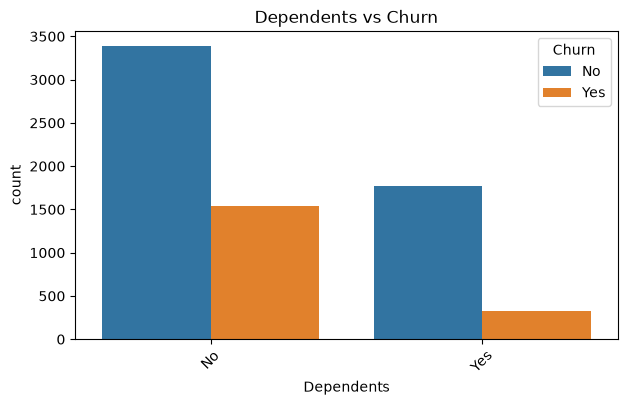

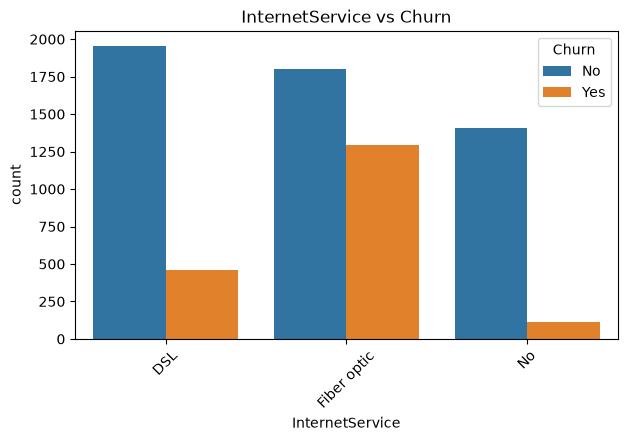

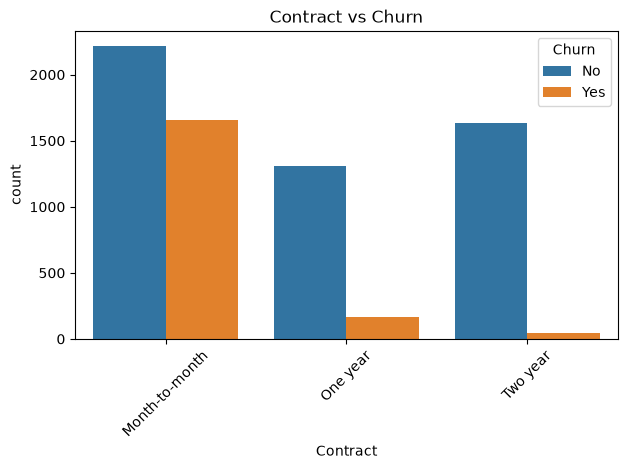

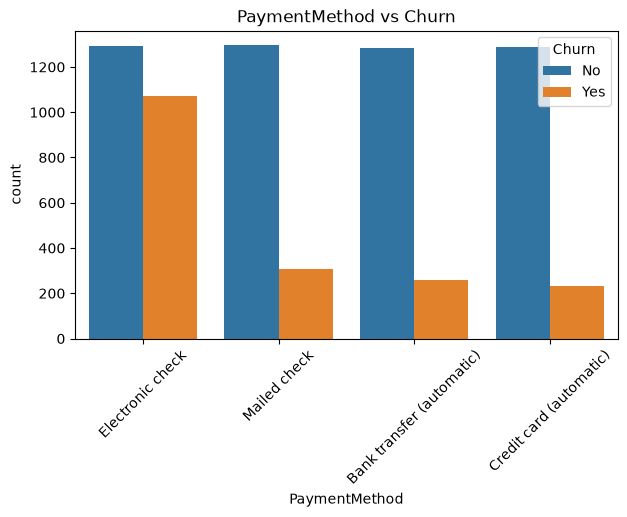

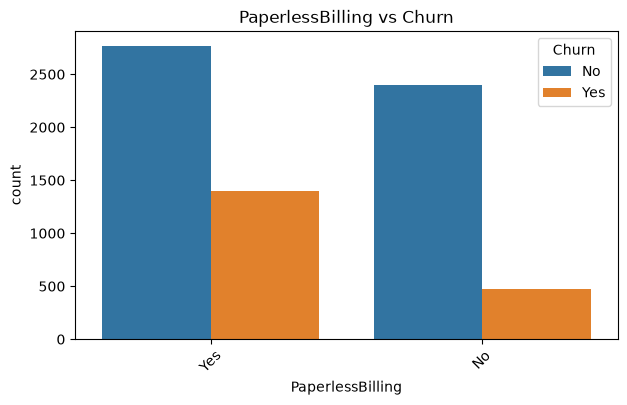

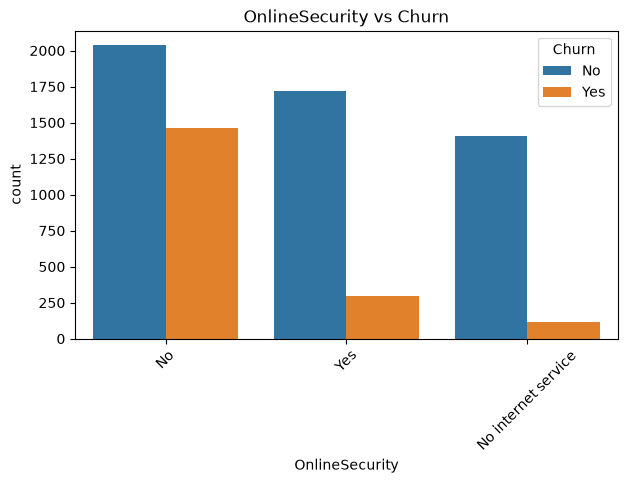

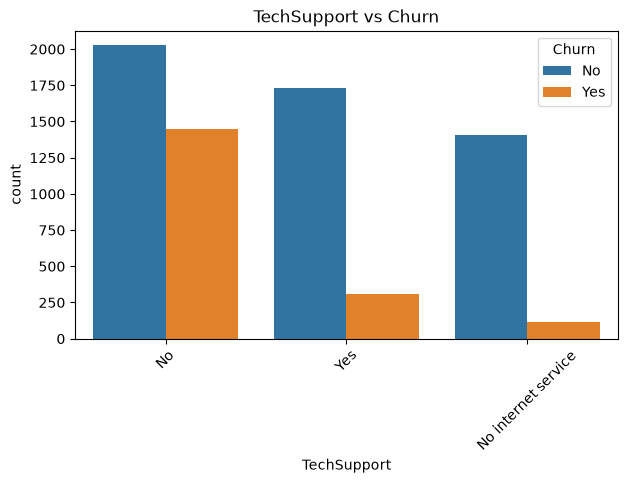

In [ ]:
categorical_columns = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'InternetService',
    'Contract',
    'PaymentMethod',
    'PaperlessBilling',
    'OnlineSecurity',
    'TechSupport'
]

for col in categorical_columns:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.show()

### Gender vs Churn

- Male and female customers exhibit very similar churn patterns.
- The churn rate is nearly equal across both genders.
- Gender does not appear to be a strong predictor of customer churn

### Senior Citizen vs Churn

- Senior citizens have a higher proportion of churn compared to non-senior customers.
- Although senior citizens are fewer in number, they leave the company more frequently.
- Senior citizens may require targeted retention strategies.

### 27. Partner vs Churn

- Customers without a partner churn more frequently than customers with a partner.
- Customers with a partner show better retention.
- Partner status appears to have a positive effect on customer loyalty.

### Dependents vs Churn

- Customers without dependents have a noticeably higher number of churn cases.
- Customers with dependents are more likely to remain with the company.
- Having dependents appears to increase customer loyalty and reduce churn.
- Dependents can be considered an important feature for churn prediction

### Internet Service vs Churn

- Fiber Optic customers show the highest number of churn cases.
- DSL customers experience comparatively lower churn.
- Customers without internet service have the lowest churn.
- Internet service type is an important factor influencing customer churn.

### Contract vs Churn

- Customers with Month-to-Month contracts have the highest churn.
- Customers with One-Year and especially Two-Year contracts have much lower churn.
- Longer contract commitments are associated with better customer retention.
- Contract type is one of the strongest factors influencing churn. 

### Payment Method vs Churn

- Customers paying through Electronic Check have the highest churn.
- Customers using Automatic Bank Transfer or Automatic Credit Card have much lower churn.
- Automatic payment methods appear to improve customer retention.

### Paperless Billing vs Churn

- Customers using Paperless Billing have a higher number of churn cases.
- Customers who do not use Paperless Billing are less likely to churn.
- Paperless Billing is associated with higher churn, although it may also be related to other factors such as contract type.

### Online Security vs Churn

- Customers without Online Security have the highest churn.
- Customers who have Online Security are much more likely to stay with the company.
- Customers without internet service have very low churn.
- Providing Online Security may improve customer retention.

### Tech Support vs Churn

- Customers without Tech Support have the highest churn.
- Customers who subscribe to Tech Support are much more likely to stay with the company.
- Customers without internet service show very low churn.
- Providing Tech Support can improve customer satisfaction and reduce churn.

### Numerical Variables vs Churn
- Box Plot

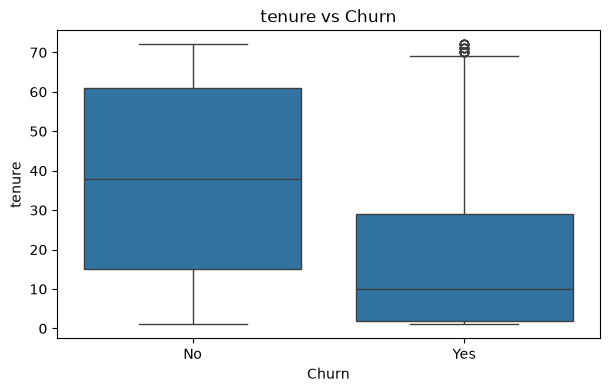

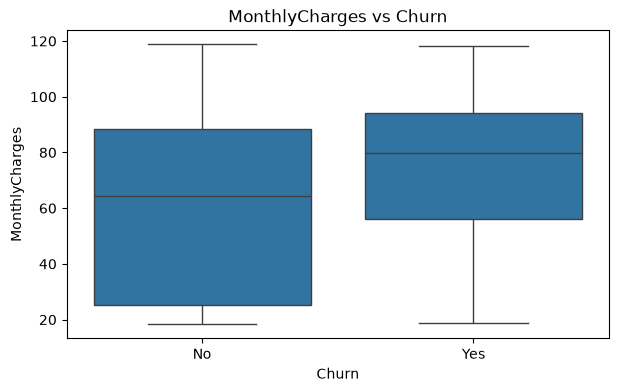

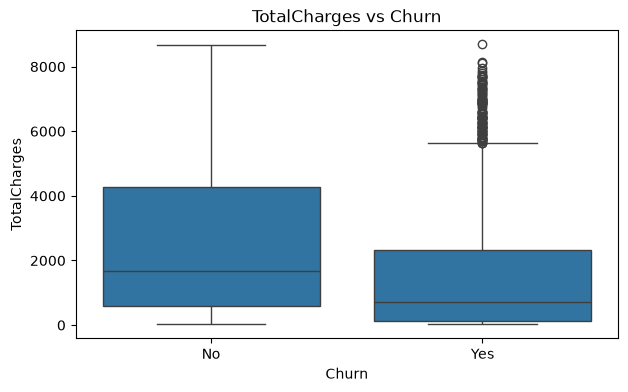

In [ ]:
numeric_col = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_col:
    plt.figure(figsize=(7,4))
    sns.boxplot(x = "Churn", y = col, data = df)
    plt.title(f'{col} vs Churn')
    plt.show()

### Tenure vs Churn

- Customers who churn generally have lower tenure than customers who stay.
- Long-term customers are much less likely to churn.
- Customer loyalty increases as tenure increases.
- Tenure is one of the strongest predictors of customer churn

### Monthly Charges vs Churn

- Customers who churn generally have higher monthly charges than customers who stay.
- Higher monthly charges appear to increase the likelihood of customer churn.

### Total Charges vs Churn

- Customers who churn generally have lower total charges than retained customers.
- Customers with higher total charges are typically long-term customers and are less likely to churn.
- Since total charges accumulate over time, this finding supports the observation that customers with longer tenure are more loyal.
- Total Charges is an important feature for predicting customer churn

## Multivariate Analysis

Analyze the combined effect of multiple variables on customer churn.

Examples include:

- Contract + InternetService + Churn
- SeniorCitizen + Contract + Churn
- MonthlyCharges + Contract + Churn
- Tenure + Contract + Churn
- Correlation Heatmap (after encoding)

<Figure size 800x500 with 0 Axes>

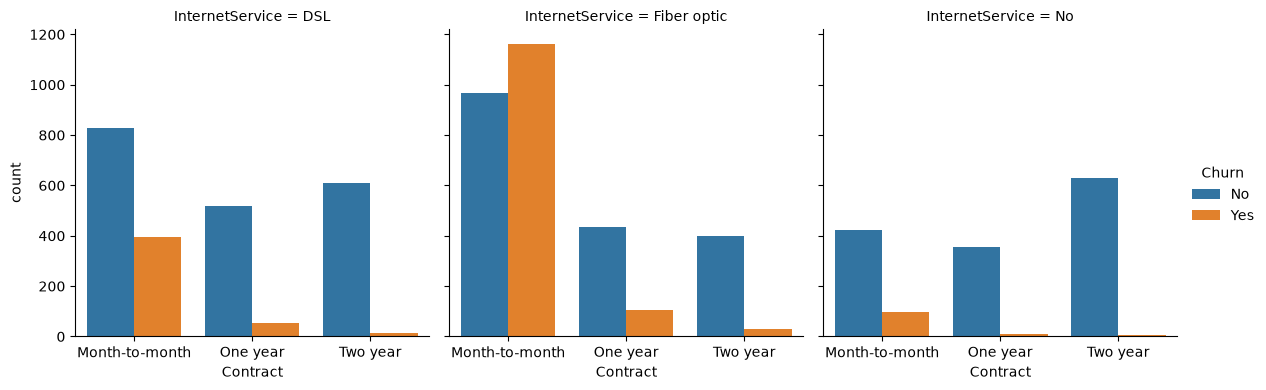

In [ ]:
plt.figure(figsize=(8,5))
sns.catplot(
    x='Contract',
    hue='Churn',
    col='InternetService',
    data=df,
    kind='count',
    height=4,
    aspect=1
)

plt.show()

### Contract + Internet Service vs Churn

- Customers using Fiber Optic internet on Month-to-Month contracts show the highest churn.
- Customers with longer contracts generally have lower churn regardless of internet service.
- Combining contract type and internet service provides a better understanding of churn behavior.
- Customers with Month-to-Month contracts may require targeted retention strategies.

<Figure size 800x500 with 0 Axes>

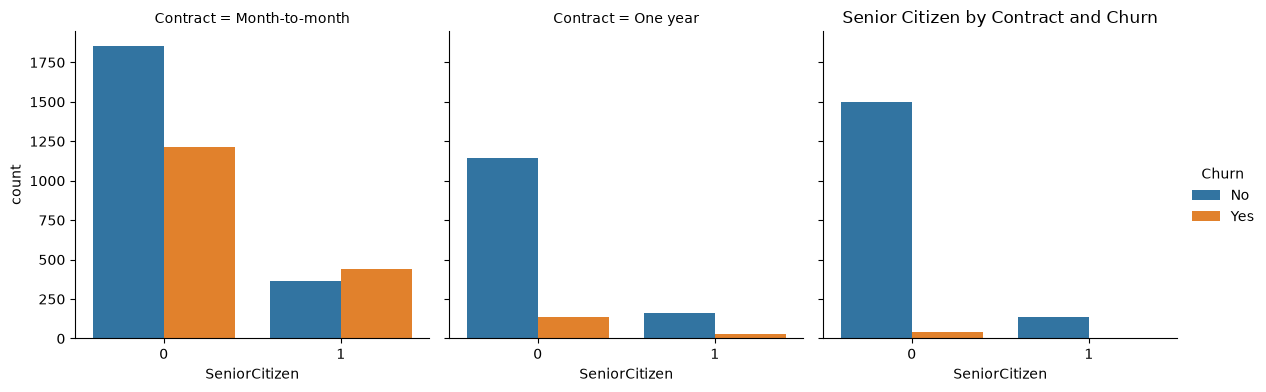

In [ ]:
plt.figure(figsize=(8,5))
sns.catplot(
    x='SeniorCitizen',
    hue='Churn',
    col='Contract',
    data=df,
    kind='count',
    height=4,
    aspect=1
)
plt.title('Senior Citizen by Contract and Churn')
plt.show()

### Senior Citizen + Contract vs Churn

- Senior citizens with Month-to-Month contracts show the highest churn.
- Churn decreases substantially for both senior and non-senior customers on One-Year and Two-Year contracts.
- Long-term contracts reduce churn across all age groups.
- Converting senior customers from Month-to-Month to long-term contracts could significantly improve retention.

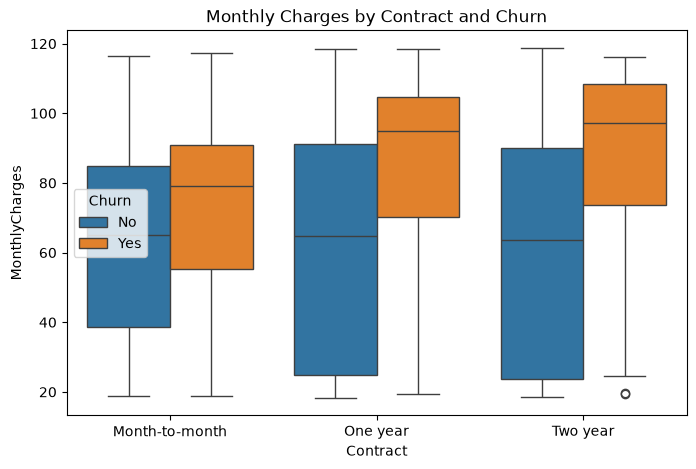

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Contract',
    y='MonthlyCharges',
    hue='Churn',
    data=df
)
plt.title('Monthly Charges by Contract and Churn')
plt.show()

### Monthly Charges + Contract vs Churn

- Customers with Month-to-Month contracts and higher monthly charges have the highest churn.
- Customers with One-Year and Two-Year contracts are more likely to stay even if they pay higher monthly charges.
- Long-term contracts reduce churn and improve customer retention.
- This suggests that encouraging customers to move from Month-to-Month to longer-term contracts could help lower churn

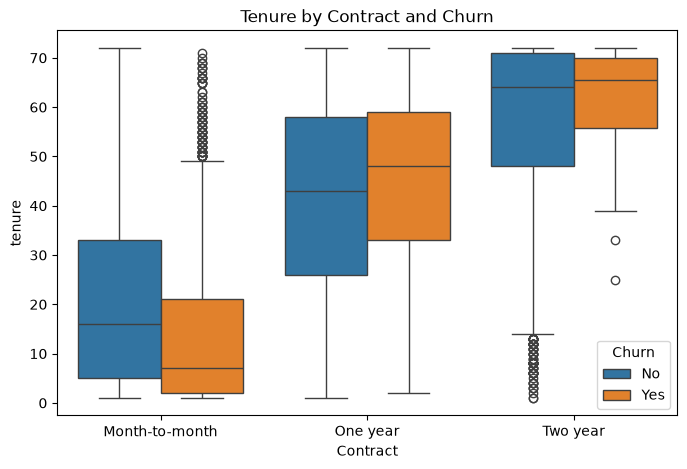

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Contract',
    y='tenure',
    hue='Churn',
    data=df
)
plt.title('Tenure by Contract and Churn')
plt.show()

### Tenure + Contract vs Churn

- Customers with Month-to-Month contracts tend to churn early, with lower tenure.
- Customers on One-Year and Two-Year contracts have significantly longer tenure and lower churn.
- Longer contracts encourage customers to stay with the company for a longer period.
- Contract type and tenure together are strong indicators of customer retention.

# Data Preprocessing for Machine Learning
## 1. Removed Unnecessary Columns

Dropped the customerID column since it is a unique identifier and does not contribute to predicting customer churn.

In [ ]:
df.drop('customerID', axis =1, inplace  = True)
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


## 2. Identified Binary and Multi-Class Categorical Features

Examined categorical columns to identify binary features (Yes/No, Male/Female) and multi-class features for appropriate encoding

In [ ]:
for col in df.select_dtypes(include = 'object').columns:
    print(col, ":", df[col].nunique())

gender : 2
Partner : 2
Dependents : 2
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
Churn : 2


C:\Users\Abc\AppData\Local\Temp\ipykernel_12480\3227305751.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include = 'object').columns:


## 3. Applied Label Encoding

Applied Label Encoding to binary categorical columns by converting two categories into numerical values (0 and 1).

In [ ]:
binary_col = ["gender", "Partner", "Dependents", "PhoneService","PaperlessBilling","Churn"]
le = LabelEncoder()

for col in binary_col:
    df[col] = le.fit_transform(df[col])
    

## 4. Applied One-Hot Encoding

Applied One-Hot Encoding to categorical columns having more than two categories. Used drop_first=True to avoid multicollinearity and reduce redundant features

In [ ]:
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity','OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract','PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(df.shape)
print(df.dtypes)
print(df.head())

(7032, 31)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSuppo

## 5. Separated Features and Target Variable

Separated the independent variables (X) from the target variable (y) for model training.

In [ ]:
X = df.drop('Churn', axis = 1)

y = df['Churn']
print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(7032, 30)
(7032,)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  \
0                 1           29.85         29.85   
1                 0           56.95       1889.50   
2                 1           53.85        108.15   
3                 0           42.30       1840.75   
4                 1           70.70        151.65   

   MultipleLines_No phone service  ...  TechSupport_Yes  \
0                            True  ...            False   
1                           False  ...            False   
2                           False  ...            False   

## 6. Performed Train-Test Split

Split the dataset into training and testing sets using an 80:20 ratio. Used stratify=y to maintain the same churn class distribution in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify=y)
print(X_train.shape, X_test.shape, y_train, y_test)


(5625, 30) (1407, 30) 1413    0
7003    0
3355    0
4494    0
3541    0
       ..
3451    0
5123    1
4135    0
4249    0
1505    1
Name: Churn, Length: 5625, dtype: int64 974     0
619     0
4289    0
3721    1
4533    0
       ..
4829    0
5176    0
2750    0
4432    0
2091    0
Name: Churn, Length: 1407, dtype: int64


## 7. Applied Feature Scaling

Standardized the numerical features (tenure, MonthlyCharges, and TotalCharges) using StandardScaler to ensure all numerical variables are on the same scale before training the machine learning model.

In [ ]:
scaler = StandardScaler()

numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

print(X_train[numerical_columns].head())
print(X_test[numerical_columns].head())

        tenure  MonthlyCharges  TotalCharges
1413  1.321816        0.981556      1.659900
7003 -0.267410       -0.971546     -0.562252
3355  1.444064        0.837066      1.756104
4494 -1.204646        0.641092     -0.908326
3541  0.669826       -0.808787     -0.101561
        tenure  MonthlyCharges  TotalCharges
974   1.077320        0.363738      0.984674
619  -1.041649        0.450100     -0.781798
4289  0.873573       -1.491376     -0.537223
3721 -1.245396       -1.473107     -0.994619
4533  1.566313        1.333645      2.308692


## 8. Verified the Processed Dataset

Verified the transformed training and testing datasets to ensure preprocessing steps were successfully applied.

In [ ]:
print(X_train.head())
print(X_test.head())

      gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
1413       1              0        1           1  1.321816             1   
7003       1              0        0           0 -0.267410             0   
3355       0              0        1           0  1.444064             1   
4494       1              0        0           0 -1.204646             1   
3541       0              0        1           0  0.669826             0   

      PaperlessBilling  MonthlyCharges  TotalCharges  \
1413                 0        0.981556      1.659900   
7003                 0       -0.971546     -0.562252   
3355                 0        0.837066      1.756104   
4494                 0        0.641092     -0.908326   
3541                 0       -0.808787     -0.101561   

      MultipleLines_No phone service  ...  TechSupport_Yes  \
1413                           False  ...             True   
7003                            True  ...             True   
3355                

# Logistic Regression Model

## Objective
Train a Logistic Regression model to predict whether a telecom customer will churn or not.

## Why Logistic Regression?

Logistic Regression is a supervised machine learning algorithm used for *binary classification* problems. Since our target variable (Churn) has only two classes (Yes/No or 1/0), Logistic Regression is an ideal baseline model.

Accuracy: 0.8045486851457001
Precision: 0.6504559270516718
Recall: 0.5721925133689839
F1: 0.6088193456614509
Confusion Matrix: [[918 115]
 [160 214]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



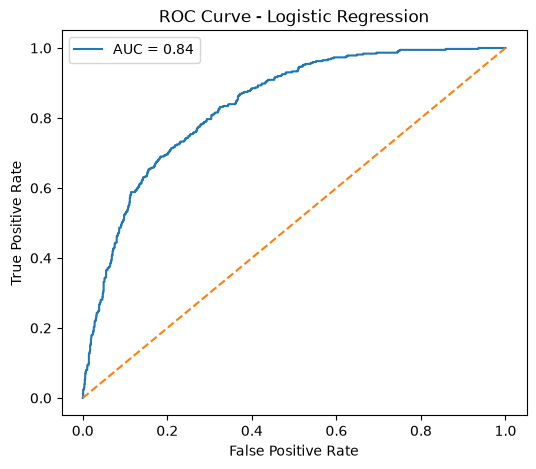

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score,roc_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#create and train the model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

#make predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

#evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)

#Classification report
print("Classification Report:", classification_report(y_test, y_pred))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# Model Performance (Inference)

## Accuracy = 80.45%

- The model correctly predicts approximately *80 out of every 100 customers*.
- Indicates good overall performance.

## Precision = 65.05%

- Out of all customers predicted as churn, *65% actually churned*.
- Around 35% were false alarms.


## Recall = 57.22%

- The model successfully identifies *57% of actual churn customers*.
- Around 43% of churn customers are missed.


## F1 Score = 60.88%

- F1 Score balances Precision and Recall.
- A score of 0.61 indicates moderate performance for churn prediction.

# Confusion Matrix

[[918 115]
 [160 214]]

### True Negative (918)

- Customer did not churn.
- Model predicted No Churn.
- Correct prediction.


### False Positive (115)

- Customer did not churn.
- Model predicted Churn.
- Incorrect prediction.


### False Negative (160)

- Customer actually churned.
- Model predicted No Churn.
- Missed churn customers.


### True Positive (214)

- Customer churned.
- Model correctly predicted Churn.

# Classification Report

## Class 0 (No Churn)

Precision = 0.85

Recall = 0.89

F1 Score = 0.87

Support = 1033

*Inference*

The model predicts customers who stay with very high accuracy.


## Class 1 (Churn)

Precision = 0.65

Recall = 0.57

F1 Score = 0.61

Support = 374

*Inference*

The model can identify churn customers reasonably well but still misses a significant number of them.


## Macro Average

Precision = 0.75

Recall = 0.73

F1 Score = 0.74

*Inference*

The model performs fairly well across both classes when each class is given equal importance.


## Weighted Average

Precision = 0.80

Recall = 0.80

F1 Score = 0.80

*Inference*

The weighted average reflects good overall performance while accounting for the class imbalance.


# ROC Curve

AUC = 0.84

### Inference

- The ROC Curve lies well above the diagonal reference line.
- An AUC score of *0.84* indicates that the model has *very good discrimination ability*.
- The model has an *84% probability* of ranking a randomly selected churn customer higher than a randomly selected non-churn customer.


# Overall Conclusion

- Logistic Regression achieved *80.45% Accuracy*.
- The model performs very well in predicting customers who stay.
- Churn prediction is moderate, with a Recall of *57%*.
- ROC-AUC score of *0.84* indicates strong classification performance.
- This model serves as a strong baseline for comparison with Decision Tree and Random Forest models in the next stage.

# Decision Tree Classifier

## Objective
Train a Decision Tree Classifier to predict customer churn and compare its performance with Logistic Regression.

## Why Decision Tree?

Decision Tree is a supervised machine learning algorithm used for classification and regression problems.

It works by repeatedly splitting the data into smaller groups based on the feature that provides the best separation between classes


Accuracy: 0.7782515991471215
Precision: 0.5807291666666666
Recall: 0.5962566844919787
F1: 0.5883905013192612
Confusion Matrix: [[872 161]
 [151 223]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



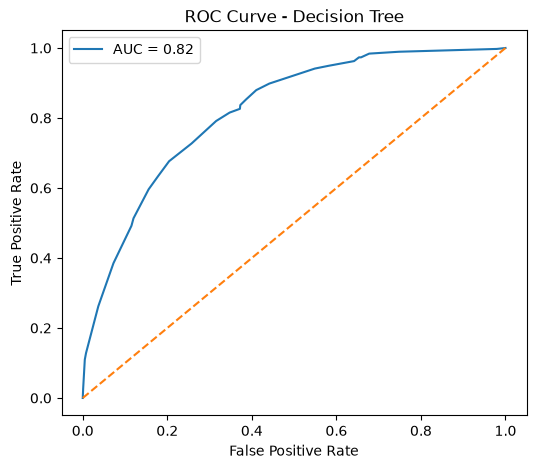

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#create and train the model
dt = DecisionTreeClassifier(max_depth= 5, random_state=42)
dt.fit(X_train, y_train)

#make predictions
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

#evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)

#Classification report
print("Classification Report:",classification_report(y_test, y_pred))

#Roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label = f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()



# Model Performance

### Accuracy
*77.83%*

The model correctly classified approximately *78%* of the customers.


### Precision
*58.07%*

Out of all customers predicted as churners, about *58%* actually churned.

### Recall
*59.63%*

The model correctly identified nearly *60%* of all actual churn customers.


### F1 Score
*58.84%*

The harmonic mean of Precision and Recall is approximately *59%*.


# Confusion Matrix

| Actual | Predicted No | Predicted Yes |
|---------|-------------:|--------------:|
| No Churn | 872 | 161 |
| Churn | 151 | 223 |

### Interpretation

- *True Negatives (872):* Correctly predicted non-churn customers.
- *False Positives (161):* Predicted churn but customer stayed.
- *False Negatives (151):* Failed to identify actual churn customers.
- *True Positives (223):* Correctly predicted churn customers.


# Classification Report

### Class 0 (No Churn)

- Precision: *0.85*
- Recall: *0.84*
- F1-score: *0.85*

The model performs well in identifying customers who stay.


### Class 1 (Churn)

- Precision: *0.58*
- Recall: *0.60*
- F1-score: *0.59*

The model struggles more in detecting churn customers compared to non-churn customers.

# ROC Curve

### AUC = 0.82

An AUC score of *0.82* indicates that the Decision Tree has good ability to distinguish between churn and non-churn customers.

The ROC curve is well above the diagonal random-guess line, showing that the model performs significantly better than random classification.

# Overall Conclusion

- Decision Tree achieved an accuracy of *77.83%*.
- It performed reasonably well but was weaker in predicting churn customers.
- Compared with Logistic Regression, the Decision Tree achieved:
  - Lower Accuracy
  - Lower Precision
  - Lower F1-score
  - Lower AUC score

Therefore, *Logistic Regression performed better than Decision Tree for this dataset.*

# Random Forest Classifier

## Objective
Train a Random Forest Classifier to predict customer churn and compare its performance with Logistic Regression and Decision Tree.



Accuracy: 0.7867803837953091
Precision: 0.6217105263157895
Recall: 0.5053475935828877
F1: 0.5575221238938053
Confusion Matrix: [[918 115]
 [185 189]]
Classification Report:               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



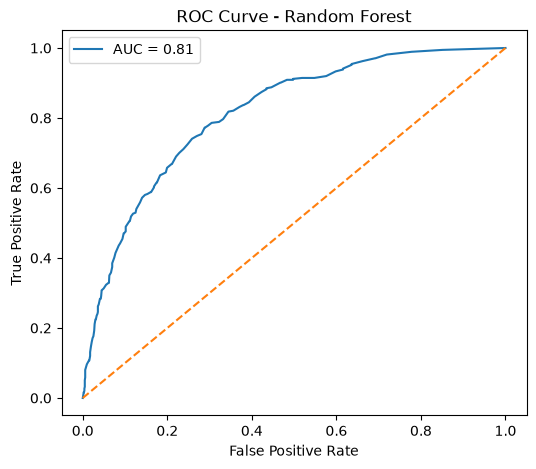

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#create and train the model
rf = RandomForestClassifier(n_estimators= 100, random_state =42)
rf.fit(X_train, y_train)

#make predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

#evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)

#Classification report
print("Classification Report:",classification_report(y_test, y_pred))

#Roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label = f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


## Model Performance

| Metric | Score |
|---------|-------|
| Accuracy | **78.68%** |
| Precision | **62.17%** |
| Recall | **50.53%** |
| F1-Score | **55.75%** |
| AUC Score | **0.81** |


## Confusion Matrix

| Actual / Predicted | No Churn | Churn |
|--------------------|---------:|------:|
| **No Churn** | 918 | 115 |
| **Churn** | 185 | 189 |


## Classification Report

### Class 0 (No Churn)
- Precision: **0.83**
- Recall: **0.89**
- F1-Score: **0.86**

### Class 1 (Churn)
- Precision: **0.62**
- Recall: **0.51**
- F1-Score: **0.56**


## ROC Curve

- **AUC Score = 0.81**
- The ROC curve is well above the diagonal line, indicating that the model performs much better than random guessing.
- An AUC of **0.81** indicates good discrimination between churn and non-churn customers.

# 📌 Inference

### 1. Accuracy
The Random Forest model achieved an **accuracy of 78.68%**, correctly classifying nearly 79 out of every 100 customers.

### 2. Precision
The model achieved a **precision of 62.17%**, meaning that when it predicts a customer will churn, the prediction is correct about 62% of the time.

### 3. Recall
The **recall is 50.53%**, indicating that the model identified approximately half of the customers who actually churned.

### 4. F1-Score
The **F1-score of 55.75%** reflects a moderate balance between precision and recall.

### 5. Confusion Matrix
- Correctly predicted **918** customers who did not churn.
- Correctly identified **189** customers who churned.
- Incorrectly predicted **115** customers as churning when they actually stayed.
- Missed **185** customers who actually churned.

### 6. ROC-AUC
An **AUC score of 0.81** shows that the Random Forest model has good ability to distinguish between churn and non-churn customers.


# Conclusion

- Random Forest achieved **78.68% accuracy**.
- The model performs well for identifying non-churn customers.
- Recall for churn customers is relatively low, meaning some churning customers are still missed.
- Compared to Logistic Regression and Decision Tree, this model can now be evaluated to determine which algorithm performs best overall for this dataset.

# XGBoost Classifier

## Objective
Train an XGBoost Classifier to predict whether a telecom customer will churn and evaluate its performance using different classification metrics.


## Model Used
- XGBoost Classifier (Extreme Gradient Boosting)
- Ensemble learning algorithm
- Builds multiple decision trees sequentially
- Each new tree corrects the mistakes made by previous trees
- Often provides better performance than a single Decision Tree

Accuracy: 0.7953091684434968
Precision: 0.6369426751592356
Recall: 0.5347593582887701
F1: 0.5813953488372093
Confusion Matrix: [[919 114]
 [174 200]]
Classification Report:               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



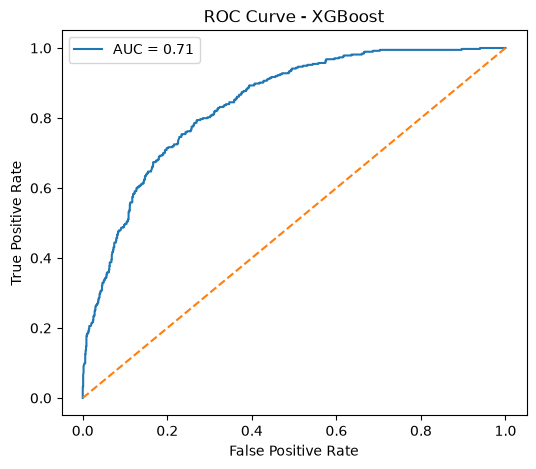

In [ ]:
from xgboost import XGBClassifier

#create and train the model
xgb = XGBClassifier(n_estimator = 100, max_depth = 3, learning_rate = 0.1, eval_metric = 'logloss', random_state = 42 )
xgb.fit(X_train, y_train)

#make predictions
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

#evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)

#Classification report
print("Classification Report:",classification_report(y_test, y_pred))

#Roc curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label= f'AUC = {auc:.2f}')
plt.plot([0,1],[0,1], linestyle = '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


## Evaluation Metrics

### Accuracy
**Accuracy = 0.7953 (79.53%)**

The model correctly predicted approximately **80%** of the customers.

### Precision
**Precision = 0.6369 (63.69%)**

Out of all customers predicted as churners, **63.69% actually churned.**

### Recall
**Recall = 0.5348 (53.48%)**

The model correctly identified **53.48%** of the actual churn customers.

### F1 Score
**F1 Score = 0.5814 (58.14%)**

The F1-score represents the balance between Precision and Recall.

## Confusion Matrix

```
[[919 114]
 [174 200]]
```

Interpretation:

- **919** → Correctly predicted Non-Churn customers (True Negatives)
- **114** → Predicted Churn but actually Non-Churn (False Positives)
- **174** → Predicted Non-Churn but customer actually Churned (False Negatives)
- **200** → Correctly predicted Churn customers (True Positives)

## Classification Report

### Class 0 (Non-Churn)

- Precision = **0.84**
- Recall = **0.89**
- F1-score = **0.86**

The model performs very well in identifying customers who will stay.

### Class 1 (Churn)

- Precision = **0.64**
- Recall = **0.53**
- F1-score = **0.58**

The model identifies churn customers reasonably well but still misses several actual churn cases.


## ROC Curve

**AUC = 0.71**

The ROC curve measures how well the model separates churn and non-churn customers.

- AUC = 0.50 → Random guessing
- AUC = 0.71 → Good discrimination
- AUC = 1.00 → Perfect classifier

# Conclusion

- Accuracy is approximately **79.5%**
- The model performs well in predicting non-churn customers.
- Precision for churn prediction is acceptable.
- Recall indicates that some churn customers are still missed.
- Overall, XGBoost provides good predictive performance but, in this run, it does not outperform the Logistic Regression model.

# Model Comparison and Final Model Selection

## Objective

The objective of this stage is to compare the performance of all trained machine learning models and select the most suitable model for predicting telecom customer churn.

# Models Evaluated

The following classification models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

# Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|--------|---------:|----------:|--------:|---------:|--------:|
| Logistic Regression | 80.45% | 65.05% | 57.22% | 60.88% | 0.84 |
| Decision Tree | 77.83% | 58.07% | 59.63% | 58.84% | 0.82 |
| Random Forest | 78.68% | 62.17% | 50.53% | 55.75% | 0.81 |
| XGBoost | 79.53% | 63.69% | 53.48% | 58.14% | 0.71 |

# Model Selection Criteria

The models were compared using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

Each metric provides different information about the model's performance. Instead of selecting a model based on a single metric, all evaluation metrics were considered together.

# Why was Logistic Regression selected?

Among all the models, **Logistic Regression** achieved the best overall performance.

### Reasons:

- Highest Accuracy (80.45%)
- Highest Precision (65.05%)
- Highest F1 Score (60.88%)
- Highest ROC-AUC Score (0.84)
- Good Recall (57.22%)

Although the Decision Tree achieved a slightly higher Recall, Logistic Regression provided a better overall balance across all evaluation metrics.

---

# Business Interpretation

In a telecom company, correctly identifying customers who are likely to churn is very important.

A good churn prediction model should:

- Correctly identify churn customers.
- Minimize false predictions.
- Generalize well on unseen customer data.

Logistic Regression provides the best balance between these requirements, making it the most suitable model for this dataset.

# Final Model Selected

**Final Selected Model: Logistic Regression**

# Conclusion

Four different machine learning algorithms were implemented and compared for customer churn prediction.

After evaluating all models using multiple performance metrics, Logistic Regression was selected as the final model because it achieved the best overall performance.

This model will be used for predicting future customer churn and can help the business identify at-risk customers and take proactive retention measures.

# Feature Importance

## Objective
The objective of this step is to understand **which customer attributes influence churn the most** and convert those findings into actionable business recommendations.

In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns,
                                   'Coefficient': log_reg.coef_[0]})

feature_importance = feature_importance.sort_values(by = 'Coefficient', ascending = False)

print("Feature Importance:", feature_importance)

Feature Importance:                                   Feature  Coefficient
11            InternetService_Fiber optic     1.121685
8                            TotalCharges     0.641811
28         PaymentMethod_Electronic check     0.386286
22                        StreamingTV_Yes     0.374880
10                      MultipleLines_Yes     0.362680
24                    StreamingMovies_Yes     0.347601
6                        PaperlessBilling     0.290723
1                           SeniorCitizen     0.195363
29             PaymentMethod_Mailed check     0.076969
18                   DeviceProtection_Yes     0.073764
27  PaymentMethod_Credit card (automatic)     0.042480
0                                  gender    -0.025018
2                                 Partner    -0.026151
16                       OnlineBackup_Yes    -0.126961
12                     InternetService_No    -0.168056
19        TechSupport_No internet service    -0.168056
23    StreamingMovies_No internet service    

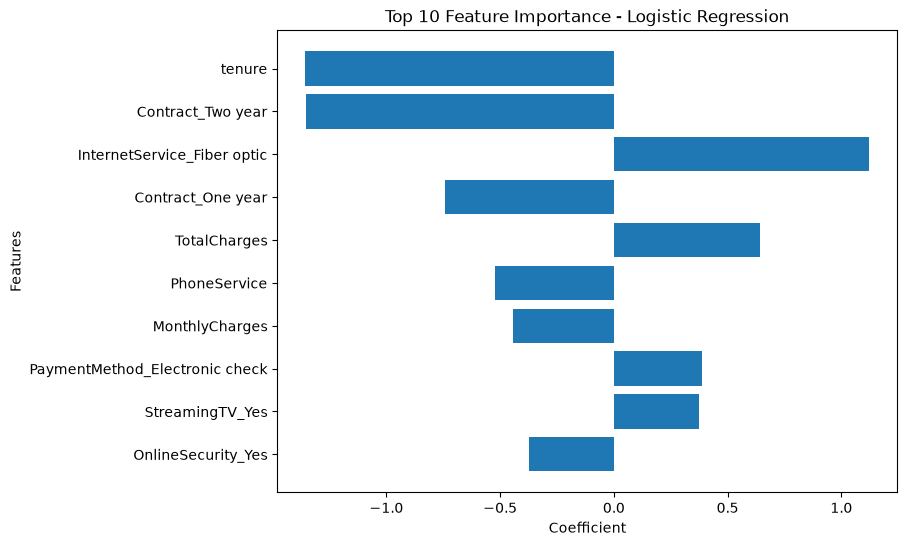

In [ ]:
top_features = feature_importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
).head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance - Logistic Regression")
plt.gca().invert_yaxis()
plt.show()

# Business Insights 

# Top Business Insights

## 1. Tenure (Most Important - Negative)

Customers with longer tenure are much less likely to churn.

### Business Insight
- Long-term customers are loyal.
- New customers have the highest risk of leaving.

### Recommendation
- Improve onboarding.
- Give rewards during the first 6–12 months.
- Launch loyalty programs.

---

## 2. Contract - Two Year (Negative)

Customers with a two-year contract rarely churn.

### Business Insight
Long-term contracts improve customer retention.

### Recommendation
- Encourage customers to upgrade to longer contracts.
- Offer discounts for two-year plans.

---

## 3. InternetService - Fiber Optic (Positive)

Fiber optic customers are more likely to churn.

### Business Insight
Although fiber offers faster internet, these customers may have:
- Higher expectations
- Higher monthly charges
- More service complaints

### Recommendation
- Improve fiber service quality.
- Offer exclusive benefits for fiber users.
- Monitor complaints from fiber customers.

---

## 4. Contract - One Year (Negative)

One-year contracts also reduce churn compared to month-to-month customers.

### Recommendation
Encourage month-to-month customers to switch to annual plans.

---

## 5. Total Charges (Positive)

Customers with higher total charges show higher churn tendency.

### Business Insight
Expensive customers may become dissatisfied if they don't perceive enough value.

### Recommendation
- Offer premium support.
- Provide personalized discounts.
- Improve customer engagement.

---

## 6. Phone Service (Negative)

Customers using phone service are slightly less likely to churn.

### Recommendation
Bundle phone services with internet plans to improve retention.

---

## 7. Monthly Charges (Positive)

Higher monthly bills increase churn probability.

### Business Insight
Price-sensitive customers may leave for cheaper competitors.

### Recommendation
- Introduce affordable plans.
- Provide discounts for high-paying customers.
- Create bundled offers.

---

## 8. Electronic Check Payment (Positive)

Customers paying through electronic check churn more frequently.

### Business Insight
Electronic check users appear less loyal than customers using automatic payment methods.

### Recommendation
- Encourage AutoPay.
- Offer cashback or discounts for automatic payments.

---

## 9. Streaming TV (Positive)

Customers using streaming TV have slightly higher churn.

### Business Insight
Entertainment customers expect uninterrupted service.

### Recommendation
- Improve streaming quality.
- Offer entertainment bundles.

---

## 10. Online Security (Negative)

Customers using Online Security are less likely to churn.

### Business Insight
Value-added services increase customer loyalty.

### Recommendation
- Promote Online Security as an add-on.
- Bundle it with internet subscriptions.

---

# Overall Business Conclusion

The strongest factors affecting churn are:

- Customer tenure
- Contract type
- Internet service type
- Monthly charges
- Payment method

Customers with:
- Long tenure
- Annual or two-year contracts
- Online Security

are less likely to churn.

Customers with:
- Fiber optic internet
- High monthly charges
- Electronic check payment
- Month-to-month contracts

are more likely to churn.

# Final Recommendation

The telecom company should:

- Focus on retaining new customers.
- Encourage long-term contracts.
- Improve Fiber Optic customer experience.
- Reduce churn among high-paying customers.
- Promote AutoPay and Online Security.
- Create personalized retention campaigns for high-risk customers.

These insights can help reduce customer churn, improve customer satisfaction, and increase long-term revenue.

# Save the model

In [ ]:
import joblib

joblib.dump(log_reg, "telecom_churn_model.pkl")

joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

print("Model and feature names saved succesfully")

Model saved successfully!
Model and feature names saved succesfully
